In [6]:
"""
Plot binned FOF classification metrics from class parquet outputs.

This script is designed to mirror the threshold/buffer workflow used by
submit_run_fof_classify.sh while focusing on binned metric-vs-magnitude plots.

What it generates:
1. Per-run, per-combo plots for all binned metrics (DD and optional LSST)
   with one subplot per linking length.
2. Cross-run comparison plots (DD only) for configured run pairs, also
   with one subplot per linking length.

Output layout (default):
    {run_dir}/plots_auto/{mag_limit}_buf{buffer}/{combo}/{metric}.png

Comparison layout (default):
    {root_run_dir}/comparisons_auto/{runA}_vs_{runB}/{mag_limit}_buf{buffer}/
        {combo}/{metric}.png
"""

from __future__ import annotations

import sys
sys.path.append('/work/hdd/bdsp/g4merz/RubinRoman/')


import argparse
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from metrics import (
    split_truth_det,
    binned_fraction,
    compute_completeness,
    compute_purity,
    compute_purity_by_det_mag,
    compute_blend_loss,
    compute_unrec_blend_frac,
    compute_shred_frac,
    compute_missed_frac,
    compute_spurious_frac,
    compute_resolved_frac,
    compute_shred_det_frac,
    compute_binned_f1,
)


In [7]:
DEFAULT_LEGEND_NAME_MAP: Dict[str, str] = {
    "lsst5": "DeepDISC Rubin",
    "comb": "DeepDISC Rubin+Roman",
    "distill": "DeepDISC-KD",
}

def canonical_run_token(run_name: str) -> str:
    """Return a compact run token used for legend aliases and folder tags."""
    lower = run_name.lower()
    if lower.startswith("lsst5"):
        return "lsst5"
    if lower.startswith("comb"):
        return "comb"
    if lower.startswith("distill"):
        return "distill"
    return run_name.split("_")[0]

def parse_legend_name_map(raw_items: List[str]) -> Dict[str, str]:
    """Parse key=value entries into a legend display-name map."""
    out: Dict[str, str] = {}
    for item in raw_items:
        if "=" not in item:
            raise ValueError(
                f"Invalid --legend-name-map entry '{item}'. Use key=value format."
            )
        key, value = item.split("=", 1)
        key = key.strip()
        value = value.strip()
        if not key or not value:
            raise ValueError(
                f"Invalid --legend-name-map entry '{item}'. Use key=value format."
            )
        out[key] = value
    return out

def get_display_name_for_run(run_name: str, legend_map: Dict[str, str]) -> str:
    """Return a user-facing display name for a run folder."""
    if run_name in legend_map:
        return legend_map[run_name]

    token = canonical_run_token(run_name)
    if token in legend_map:
        return legend_map[token]

    prefix = run_name.split("_")[0]
    if prefix in legend_map:
        return legend_map[prefix]

    return prefix



MAG_LIMITS: Dict[str, float] = {
    "power_law": 26.22,
    "gold": 25.3,
    "nominal": 26.42,
}


@dataclass(frozen=True)
class MetricSpec:
    """Metadata for one binned metric plot."""

    key: str
    title: str
    y_label: str


METRICS: List[MetricSpec] = [
    MetricSpec("f1", "F1 Score vs Magnitude", "F1 Score"),
    MetricSpec("completeness", "Completeness vs Magnitude", "Completeness"),
    MetricSpec(
        "completeness_isolated",
        "Completeness (Isolated) vs Magnitude",
        "Completeness",
    ),
    MetricSpec(
        "completeness_blended",
        "Completeness (Blended) vs Magnitude",
        "Completeness",
    ),
    MetricSpec(
        "purity_by_truth_mag",
        "Purity (Truth Mag) vs Magnitude",
        "Purity",
    ),
    MetricSpec(
        "purity_by_det_mag",
        "Purity (Det Mag) vs Magnitude",
        "Purity",
    ),
    MetricSpec("blend_loss", "Blend Loss Fraction vs Magnitude", "Fraction"),
    MetricSpec(
        "unrec_blend_frac",
        "Unrecognized Blend Fraction vs Magnitude",
        "Unrecognized Blend Fraction",
    ),
    MetricSpec(
        "unrec_blend_frac_blended",
        "Unrecognized Blend Fraction (Blended Truths) vs Magnitude",
        "Unrecognized Blend Fraction",
    ),
    MetricSpec(
        "unrec_blend_frac_matched",
        "Unrecognized Blend Fraction (Matched Truths) vs Magnitude",
        "Unrecognized Blend Fraction",
    ),
    MetricSpec("shred_frac", "Shred Fraction (Truth) vs Magnitude", "Shredded Fraction"),
    MetricSpec("missed_frac", "Missed Fraction vs Magnitude", "Missed Fraction"),
    MetricSpec(
        "spurious_frac",
        "Spurious Fraction (Det) vs Magnitude",
        "Spurious Fraction",
    ),
    MetricSpec("resolved_frac", "Resolved Fraction vs Magnitude", "Fraction"),
    MetricSpec(
        "shred_det_frac",
        "Shred Fraction (Det) vs Magnitude",
        "Resolved Fraction",
    ),
]


FIXED_ONE_YMAX_METRICS = {
    "f1",
    "completeness",
    "completeness_by_det_mag",
    "completeness_isolated",
    "completeness_blended",
    "purity_by_truth_mag",
    "purity_by_det_mag",
    "resolved_frac",
}


In [8]:
def get_panel_ymax(metric_key: str, series_list: Sequence[np.ndarray]) -> float:
    """Return y-axis max for a panel using fixed or dynamic scaling."""
    if metric_key in FIXED_ONE_YMAX_METRICS:
        return 1.0

    finite_maxes: List[float] = []
    for series in series_list:
        arr = np.asarray(series, dtype=float)
        finite = arr[np.isfinite(arr)]
        if finite.size > 0:
            finite_maxes.append(float(np.max(finite)))

    if not finite_maxes:
        return 1.0

    return max(finite_maxes) + 0.3


def build_combo_labels(
    score_thresholds: Sequence[str],
    nms_thresholds: Sequence[str],
    cartesian: bool,
) -> List[str]:
    """Build threshold combo labels like s0.5_n0.6."""
    combos: List[str] = []
    if cartesian:
        for s in score_thresholds:
            for n in nms_thresholds:
                combos.append(f"s{s}_n{n}")
        return combos

    if len(score_thresholds) != len(nms_thresholds):
        raise ValueError(
            "Score and NMS threshold lists must have same length unless --combo is set"
        )
    for s, n in zip(score_thresholds, nms_thresholds):
        combos.append(f"s{s}_n{n}")
    return combos


def parse_run_pairs(raw_pairs: Sequence[str]) -> List[Tuple[str, str]]:
    """Parse run pair strings in the form runA,runB."""
    pairs: List[Tuple[str, str]] = []
    for raw in raw_pairs:
        parts = [p.strip() for p in raw.split(",")]
        if len(parts) != 2 or not parts[0] or not parts[1]:
            raise ValueError(
                f"Invalid run pair '{raw}'. Use format: runA,runB"
            )
        pairs.append((parts[0], parts[1]))
    return pairs


def parse_combo_map(raw_maps: Sequence[str]) -> List[Tuple[str, str]]:
    """Parse combo map entries in the form left_combo:right_combo."""
    combo_pairs: List[Tuple[str, str]] = []
    for raw in raw_maps:
        parts = [p.strip() for p in raw.split(":")]
        if len(parts) != 2 or not parts[0] or not parts[1]:
            raise ValueError(
                f"Invalid combo map '{raw}'. Use format: left_combo:right_combo"
            )
        combo_pairs.append((parts[0], parts[1]))
    return combo_pairs


def get_mag_limit_value(mag_limit: str, buffer_val: int) -> float:
    """Return numeric mag limit after applying buffer."""
    return MAG_LIMITS[mag_limit] + float(buffer_val)


def load_analysis_df(
    run_dir: Path,
    prefix: str,
    linking_length: str,
    combo: str,
    mag_limit_val: float,
    buffer_val: float,
) -> Optional[pd.DataFrame]:
    """Load one classified analysis parquet for DD or LSST."""
    cats_dir = run_dir / "analysis_cats"
    if prefix == "dd":
        parquet = (
            cats_dir
            / "dd"
            / linking_length
            / combo
            / f"class_{mag_limit_val:.2f}.parquet"
        )
    else:
        parquet = (
            cats_dir
            / "lsst"
            / linking_length
            / f"class_{mag_limit_val:.2f}.parquet"
        )

    if not parquet.exists():
        return None
    df = pd.read_parquet(parquet)

    df_add_sigblend = is_sig_blend(df,buffer_val)
    return df_add_sigblend

def is_sig_blend(df,deltam=2):
    '''
    Adds an is_sig_blend flag to the analysis dataframe.  This is based on the difference between the max i band mag 
    and min i band mag for objects within an FOF group.  If the difference is less than 2, the blend is significant.
    Greater mag differences will probably not influence color/shape measurements

    '''
    gdf = df.copy()
    group_counts = df.groupby('group_id').size().reset_index(name='object_count')
    gdf['group_counts'] = gdf.groupby('group_id').transform('size')

    for f in ['u','g','r','i','z','y']:
        gdf[f'min_blend_mag_{f}'] = gdf[f'mag_{f}'].where(gdf['catalog_key'] == f'lsst_truth').groupby(gdf['group_id']).transform('min')
        gdf[f'max_blend_mag_{f}'] = gdf[f'mag_{f}'].where(gdf['catalog_key'] == f'lsst_truth').groupby(gdf['group_id']).transform('max')
        
    gdf[f'min_size'] = gdf[f'size'].where(gdf['catalog_key'] == f'lsst_truth').groupby(gdf['group_id']).transform('min')
    gdf['significant_blend'] = (gdf['max_blend_mag_i']-gdf['min_blend_mag_i'])<deltam
    
    return gdf




In [9]:

def compute_unrec_blend_by_det(dets,prefix, mag_bins, mag_col='mag_i',
                              min_count=1):
    valid = (np.isfinite(dets[mag_col].values) & (dets['significant_blend']))
    results =  binned_fraction(
        dets[f'{prefix}_is_unrec_blend'].values[valid],
        dets[mag_col].values[valid],
        mag_bins,
        min_count=min_count,
    )

    return results

def compute_completeness_by_det(dets,prefix, mag_bins, mag_col='mag_i',
                              min_count=1):
    valid = np.isfinite(dets[mag_col].values)
    results =  binned_fraction(
        dets[f'{prefix}_is_matched'].values[valid],
        dets[mag_col].values[valid],
        mag_bins,
        min_count=min_count,
    )

    return results


def compute_metric(
    metric_key: str,
    truths: pd.DataFrame,
    dets: pd.DataFrame,
    prefix: str,
    mag_bins: np.ndarray,
    min_count: int,
) -> Dict[str, np.ndarray]:
    """Compute one metric result dict with fraction and CI arrays."""
    if metric_key == "completeness":
        return compute_completeness(
            truths,
            prefix,
            mag_bins,
            min_count=min_count,
        )

    if metric_key == "completeness_by_det_mag":
        return compute_completeness_by_det(
            dets,
            prefix,
            mag_bins,
            min_count=min_count,
        )

    if metric_key == "f1":
        return compute_binned_f1(
            truths,
            dets,
            prefix,
            mag_bins,
            min_count=min_count,
        )

    if metric_key == "completeness_isolated":
        mask = ~truths[f"{prefix}_is_part_of_blend"].values.astype(bool)
        return compute_completeness(
            truths,
            prefix,
            mag_bins,
            subset_mask=mask,
            min_count=min_count,
        )

    if metric_key == "completeness_blended":
        mask = truths[f"{prefix}_is_part_of_blend"].values.astype(bool)
        return compute_completeness(
            truths,
            prefix,
            mag_bins,
            subset_mask=mask,
            min_count=min_count,
        )

    if metric_key == "purity_by_truth_mag":
        return compute_purity(
            dets,
            truths,
            prefix,
            mag_bins,
            min_count=min_count,
        )

    if metric_key == "purity_by_det_mag":
        return compute_purity_by_det_mag(
            dets,
            prefix,
            mag_bins,
            min_count=min_count,
        )

    if metric_key == "blend_loss":
        return compute_blend_loss(
            truths,
            prefix,
            mag_bins,
            min_count=min_count,
        )

    if metric_key == "unrec_blend_frac":
        return compute_unrec_blend_frac(
            truths,
            prefix,
            mag_bins,
            min_count=min_count,
        )

    if metric_key == "unrec_blend_frac_by_det_mag":
        return compute_unrec_blend_by_det(
            dets,
            prefix,
            mag_bins,
            min_count=min_count,
        )

    if metric_key == "unrec_blend_frac_blended":
        blend_mask = truths[f"{prefix}_is_part_of_blend"].values.astype(bool)
        t = truths[blend_mask]
        if len(t) == 0:
            n_bins = len(mag_bins) - 1
            return {
                "bin_centers": 0.5 * (mag_bins[:-1] + mag_bins[1:]),
                "fractions": np.full(n_bins, np.nan),
                "ci_lo": np.full(n_bins, np.nan),
                "ci_hi": np.full(n_bins, np.nan),
                "counts": np.zeros(n_bins, dtype=int),
                "flagged_counts": np.zeros(n_bins, dtype=int),
            }
        return binned_fraction(
            t[f"{prefix}_is_unrec_blend"],
            t["mag_i"],
            mag_bins,
            min_count=min_count,
        )

    if metric_key == "unrec_blend_frac_matched":
        matched_mask = truths[f"{prefix}_is_matched"].values.astype(bool)
        t = truths[matched_mask]
        if len(t) == 0:
            n_bins = len(mag_bins) - 1
            return {
                "bin_centers": 0.5 * (mag_bins[:-1] + mag_bins[1:]),
                "fractions": np.full(n_bins, np.nan),
                "ci_lo": np.full(n_bins, np.nan),
                "ci_hi": np.full(n_bins, np.nan),
                "counts": np.zeros(n_bins, dtype=int),
                "flagged_counts": np.zeros(n_bins, dtype=int),
            }
        return binned_fraction(
            t[f"{prefix}_is_unrec_blend"],
            t["mag_i"],
            mag_bins,
            min_count=min_count,
        )

    if metric_key == "shred_frac":
        return compute_shred_frac(
            truths,
            prefix,
            mag_bins,
            min_count=min_count,
        )

    if metric_key == "missed_frac":
        return compute_missed_frac(
            truths,
            prefix,
            mag_bins,
            min_count=min_count,
        )

    if metric_key == "spurious_frac":
        return compute_spurious_frac(
            dets,
            prefix,
            mag_bins,
            min_count=min_count,
        )

    if metric_key == "resolved_frac":
        return compute_resolved_frac(
            truths,
            prefix,
            mag_bins,
            min_count=min_count,
        )

    if metric_key == "shred_det_frac":
        return compute_shred_det_frac(
            dets,
            prefix,
            mag_bins,
            min_count=min_count,
        )

    raise ValueError(f"Unsupported metric key: {metric_key}")

In [10]:
def plot_metric_panels(
    metric: MetricSpec,
    linking_lengths: Sequence[str],
    dd_by_ll: Dict[str, Dict[str, np.ndarray]],
    lsst_by_ll: Dict[str, Dict[str, np.ndarray]],
    out_path: Path,
    figure_title: str,
    include_lsst: bool,
    buffer_val: int,
    mag_limit_val: str
) -> None:
    """Plot one metric with one panel per linking length."""
    n_ll = len(linking_lengths)
    fig, axes = plt.subplots(1, n_ll, figsize=(8 * n_ll, 6), squeeze=False)

    for idx, ll in enumerate(linking_lengths):
        ax = axes[0, idx]

        if ll in dd_by_ll:
            dd = dd_by_ll[ll]
            dd_mask = np.isfinite(dd["fractions"])
            ax.plot(
                dd["bin_centers"][dd_mask],
                dd["fractions"][dd_mask],
                color="tab:blue",
                linestyle="-",
                marker="o",
                markersize=4,
                label="DD",
            )
            ci_mask = (
                dd_mask
                & np.isfinite(dd["ci_lo"])
                & np.isfinite(dd["ci_hi"])
            )
            if np.any(ci_mask):
                ax.fill_between(
                    dd["bin_centers"][ci_mask],
                    dd["ci_lo"][ci_mask],
                    dd["ci_hi"][ci_mask],
                    color="tab:blue",
                    alpha=0.15,
                )

        if include_lsst and ll in lsst_by_ll:
            lsst = lsst_by_ll[ll]
            lsst_mask = np.isfinite(lsst["fractions"])
            ax.plot(
                lsst["bin_centers"][lsst_mask],
                lsst["fractions"][lsst_mask],
                color="tab:green",
                linestyle="--",
                marker="o",
                markersize=4,
                label="LSST",
            )
            ci_mask = (
                lsst_mask
                & np.isfinite(lsst["ci_lo"])
                & np.isfinite(lsst["ci_hi"])
            )
            if np.any(ci_mask):
                ax.fill_between(
                    lsst["bin_centers"][ci_mask],
                    lsst["ci_lo"][ci_mask],
                    lsst["ci_hi"][ci_mask],
                    color="tab:green",
                    alpha=0.15,
                )

        ax.set_xlabel("mag i", fontsize=16)
        ax.set_ylabel(metric.y_label, fontsize=16)
        ax.set_title(f"LL={ll}\""+rf", $\Delta$m={buffer_val}", fontsize=16)
        ax.grid(True, alpha=0.3)
        panel_ymax = get_panel_ymax(
            metric.key,
            [
                dd_by_ll.get(ll, {}).get("fractions", np.asarray([])),
                lsst_by_ll.get(ll, {}).get("fractions", np.asarray([])),
            ],
        )
        ax.set_ylim(-0.02, panel_ymax)
        ax.legend(fontsize=12)
        ax.tick_params(axis='both', which='major', labelsize=14)
        mlim=float(mag_limit_val)
        ax.axvline(mlim,color='k',linestyle='--')
        ax.axvline(mlim-buffer_val,color='grey')


    #fig.suptitle(figure_title, fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def plot_pair_metric_panels(
    metric: MetricSpec,
    linking_lengths: Sequence[str],
    run_a: str,
    run_b: str,
    run_a_by_ll: Dict[str, Dict[str, np.ndarray]],
    run_b_by_ll: Dict[str, Dict[str, np.ndarray]],
    out_path: Path,
    figure_title: str,
    buffer_val: int,
    mag_limit_val: str
) -> None:
    """Plot one cross-run metric figure with one panel per linking length."""
    n_ll = len(linking_lengths)
    fig, axes = plt.subplots(1, n_ll, figsize=(8 * n_ll, 6), squeeze=False)


    for idx, ll in enumerate(linking_lengths):
        ax = axes[0, idx]

        # Plot run A
        if ll in run_a_by_ll:
            a = run_a_by_ll[ll]
            mask = np.isfinite(a["fractions"])
            ax.plot(
                a["bin_centers"][mask],
                a["fractions"][mask],
                color="tab:blue",
                linestyle="-",
                marker="o",
                markersize=4,
                label=get_display_name_for_run(run_a,legend_name_map)
            )
            # Error bands for run A
            if "ci_lo" in a and "ci_hi" in a:
                ci_mask = mask & np.isfinite(a["ci_lo"]) & np.isfinite(a["ci_hi"])
                if np.any(ci_mask):
                    ax.fill_between(
                        a["bin_centers"][ci_mask],
                        a["ci_lo"][ci_mask],
                        a["ci_hi"][ci_mask],
                        color="tab:blue",
                        alpha=0.18,
                        linewidth=0,
                        #label=f"{run_a} CI"
                    )

        # Plot run B
        if ll in run_b_by_ll:
            b = run_b_by_ll[ll]
            mask = np.isfinite(b["fractions"])
            ax.plot(
                b["bin_centers"][mask],
                b["fractions"][mask],
                color="tab:red",
                linestyle="-",
                marker="o",
                markersize=4,
                label=get_display_name_for_run(run_b,legend_name_map)
            )
            # Error bands for run B
            if "ci_lo" in b and "ci_hi" in b:
                ci_mask = mask & np.isfinite(b["ci_lo"]) & np.isfinite(b["ci_hi"])
                if np.any(ci_mask):
                    ax.fill_between(
                        b["bin_centers"][ci_mask],
                        b["ci_lo"][ci_mask],
                        b["ci_hi"][ci_mask],
                        color="tab:red",
                        alpha=0.18,
                        linewidth=0,
                        #label=f"{run_b} CI"
                    )

        ax.set_xlabel("mag i", fontsize=16)
        ax.set_ylabel(metric.y_label, fontsize=16)
        #ax.set_title(f"LL={ll}\"", fontsize=16)
        ax.set_title(f"LL={ll}\""+rf", $\Delta$m={buffer_val}", fontsize=16)
        ax.grid(True, alpha=0.3)
        panel_ymax = get_panel_ymax(
            metric.key,
            [
                run_a_by_ll.get(ll, {}).get("fractions", np.asarray([])),
                run_b_by_ll.get(ll, {}).get("fractions", np.asarray([])),
            ],
        )
        ax.set_ylim(-0.02, panel_ymax)
        ax.legend(fontsize=12)
        ax.tick_params(axis='both', which='major', labelsize=14)
        mlim=float(mag_limit_val)
        ax.axvline(mlim,color='k',linestyle='--')
        ax.axvline(mlim-buffer_val,color='grey')


    #fig.suptitle(figure_title, fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


In [11]:
get_mag_limit_value('gold', 1)


26.3

In [12]:
def run_per_run_plots(
    root_run_dir: Path,
    run_names: Sequence[str],
    combos: Sequence[str],
    buffers: Sequence[int],
    linking_lengths: Sequence[str],
    mag_limit: str,
    mag_bins: np.ndarray,
    min_count: int,
    include_lsst: bool,
    output_subdir: str,
) -> None:
    """Generate per-run, per-combo all-metric plots."""
    for run_name in run_names:
        run_dir = root_run_dir / run_name
        if not run_dir.exists():
            print(f"WARNING: run directory not found, skipping: {run_dir}")
            continue

        for buffer_val in buffers:
            mag_limit_val = get_mag_limit_value(mag_limit, buffer_val)
            for combo in combos:
                print(
                    "Generating run plots:",
                    f"run={run_name}",
                    f"buffer={buffer_val}",
                    f"combo={combo}",
                )
                for metric in METRICS:
                    dd_results: Dict[str, Dict[str, np.ndarray]] = {}
                    lsst_results: Dict[str, Dict[str, np.ndarray]] = {}

                    for ll in linking_lengths:
                        dd_df = load_analysis_df(
                            run_dir,
                            "dd",
                            ll,
                            combo,
                            mag_limit_val,
                            buffer_val
                        )
                        if dd_df is not None:
                            truths_dd, dets_dd = split_truth_det(dd_df, "dd")
                            dd_results[ll] = compute_metric(
                                metric.key,
                                truths_dd,
                                dets_dd,
                                "dd",
                                mag_bins,
                                min_count,
                            )

                        if include_lsst:
                            lsst_df = load_analysis_df(
                                run_dir,
                                "lsst",
                                ll,
                                combo,
                                mag_limit_val,
                                buffer_val
                            )
                            if lsst_df is not None:
                                truths_lsst, dets_lsst = split_truth_det(
                                    lsst_df,
                                    "lsst",
                                )
                                lsst_results[ll] = compute_metric(
                                    metric.key,
                                    truths_lsst,
                                    dets_lsst,
                                    "lsst",
                                    mag_bins,
                                    min_count,
                                )

                    if not dd_results and not lsst_results:
                        continue

                    out_path = (
                        run_dir
                        / output_subdir
                        / f"{mag_limit}_buf{buffer_val}"
                        / combo
                        / f"{metric.key}.png"
                    )
                    figure_title = (
                        f"{run_name} | {combo} | {metric.title} | "
                        f"{mag_limit}+{buffer_val}"
                    )
                    plot_metric_panels(
                        metric,
                        linking_lengths,
                        dd_results,
                        lsst_results,
                        out_path,
                        figure_title,
                        include_lsst,
                        buffer_val,
                        mag_limit_val
                    )


In [13]:
def run_pair_comparisons(
    root_run_dir: Path,
    run_pairs: Sequence[Tuple[str, str]],
    combos: Sequence[str],
    mapped_combo_pairs: Sequence[Tuple[str, str]],
    buffers: Sequence[int],
    linking_lengths: Sequence[str],
    mag_limit: str,
    mag_bins: np.ndarray,
    min_count: int,
    comparison_subdir: str,
) -> None:
    """Generate cross-run comparison plots (DD only)."""
    combo_items: List[Tuple[str, str, str]]
    if mapped_combo_pairs:
        combo_items = [
            (left_combo, right_combo, f"{left_combo}_vs_{right_combo}")
            for left_combo, right_combo in mapped_combo_pairs
        ]
    else:
        combo_items = [(combo, combo, combo) for combo in combos]

    for run_a, run_b in run_pairs:
        run_a_dir = root_run_dir / run_a
        run_b_dir = root_run_dir / run_b
        if not run_a_dir.exists() or not run_b_dir.exists():
            print(
                f"WARNING: comparison pair skipped (missing run dir): {run_a}, {run_b}"
            )
            continue

        for buffer_val in buffers:
            mag_limit_val = get_mag_limit_value(mag_limit, buffer_val)
            for combo_a, combo_b, combo_tag in combo_items:
                combo_has_data = False
                for metric in METRICS:
                    a_results: Dict[str, Dict[str, np.ndarray]] = {}
                    b_results: Dict[str, Dict[str, np.ndarray]] = {}

                    for ll in linking_lengths:
                        dd_a = load_analysis_df(
                            run_a_dir,
                            "dd",
                            ll,
                            combo_a,
                            mag_limit_val,
                            buffer_val
                        )
                        dd_b = load_analysis_df(
                            run_b_dir,
                            "dd",
                            ll,
                            combo_b,
                            mag_limit_val,
                            buffer_val
                        )
                        if dd_a is None or dd_b is None:
                            # In mapped mode, skip when either mapped combo is missing.
                            continue

                        truths_a, dets_a = split_truth_det(dd_a, "dd")
                        truths_b, dets_b = split_truth_det(dd_b, "dd")
                        a_results[ll] = compute_metric(
                            metric.key,
                            truths_a,
                            dets_a,
                            "dd",
                            mag_bins,
                            min_count,
                        )
                        b_results[ll] = compute_metric(
                            metric.key,
                            truths_b,
                            dets_b,
                            "dd",
                            mag_bins,
                            min_count,
                        )

                    if not a_results or not b_results:
                        continue

                    combo_has_data = True
                    out_path = (
                        root_run_dir
                        / comparison_subdir
                        / f"{run_a}_vs_{run_b}"
                        / f"{mag_limit}_buf{buffer_val}"
                        / combo_tag
                        / f"{metric.key}.png"
                    )
                    title = (
                        f"{run_a} ({combo_a}) vs {run_b} ({combo_b}) | "
                        f"{metric.title} | "
                        f"{mag_limit}+{buffer_val}"
                    )
                    plot_pair_metric_panels(
                        metric,
                        linking_lengths,
                        run_a,
                        run_b,
                        a_results,
                        b_results,
                        out_path,
                        title,
                        buffer_val,
                        mag_limit_val
                    )

                if not combo_has_data:
                    print(
                        "WARNING: no matched DD data for comparison:",
                        f"pair={run_a},{run_b}",
                        f"buffer={buffer_val}",
                        f"combo_a={combo_a}",
                        f"combo_b={combo_b}",
                    )

In [14]:
root_run_dir = '/work/hdd/bdsp/yse2/lsst_runs/'
#run_names = ['lsst5_30k_4h200_bs192_ep50']
run_names = [['lsst5_30k_4h200_bs192_ep50', 'comb_30k_4h200_bs144_ep50']]

output_subdir = '/work/hdd/bdsp/g4merz/RubinRoman/plots/'
mag_min = 18.0
mag_max=28.0
mag_bin_width=0.5
min_count=1
buffers = [1,2]
linking_lengths = ['1.0']
mag_limit='gold'
#combos = ['s0.5_n0.6']
combos = build_combo_labels(
        ['0.5','0.55'],
        ['0.65','0.7'],
        False,
    )
mag_bins = np.arange(
        mag_min,
        mag_max + 0.01,
        mag_bin_width,
    )

root_run_dir = Path(root_run_dir).expanduser().resolve()
comparison_subdir = Path(output_subdir) / "comb_comp/"
comp_combo_map = ["s0.5_n0.6:s0.55_n0.65"]
mapped_pairs = parse_combo_map(comp_combo_map)

legend_name_map = []
user_legend_map = parse_legend_name_map(legend_name_map)
legend_name_map = DEFAULT_LEGEND_NAME_MAP.copy()
legend_name_map.update(user_legend_map)
METRICS: List[MetricSpec] = [
    MetricSpec("completeness", "Completeness vs Magnitude", "Completeness"),
    MetricSpec("unrec_blend_frac_by_det_mag", "Unrecognized Blend Fraction vs (Det) Magnitude",
        "Unrecognized Blend Fraction"),
    MetricSpec("purity_by_det_mag", "Purity (Det Mag) vs Magnitude",
               "Purity"),
]
#    MetricSpec("completeness_by_det_mag", "Completeness vs (Det) Magnitude",
#        "Completeness"),
#    MetricSpec("purity_by_det_mag", "Purity (Det Mag) vs Magnitude",
#               "Purity")
#]

In [27]:
#METRICS = METRICS[1:]
#METRICS

In [88]:
run_per_run_plots(
    root_run_dir=root_run_dir,
    run_names=run_names,
    combos=combos,
    buffers=buffers,
    linking_lengths=linking_lengths,
    mag_limit=mag_limit,
    mag_bins=mag_bins,
    min_count=min_count,
    include_lsst=True,
    output_subdir=output_subdir,
)

Generating run plots: run=lsst5_30k_4h200_bs192_ep50 buffer=1 combo=s0.5_n0.6
Generating run plots: run=lsst5_30k_4h200_bs192_ep50 buffer=2 combo=s0.5_n0.6


In [91]:
run_pair_comparisons(
    root_run_dir=root_run_dir,
    run_pairs=run_names,
    combos=combos,
    mapped_combo_pairs=mapped_pairs,
    buffers= [1,2],
    linking_lengths= ['1.0'],
    mag_limit= mag_limit,
    mag_bins= mag_bins,
    min_count= min_count,
    comparison_subdir= comparison_subdir
)

In [15]:
baseline_run_dir = root_run_dir / run_names[0][0]
print(baseline_run_dir)

roman_run_dir = root_run_dir / run_names[0][1]
print(roman_run_dir)


/work/hdd/bdsp/yse2/lsst_runs/lsst5_30k_4h200_bs192_ep50
/work/hdd/bdsp/yse2/lsst_runs/comb_30k_4h200_bs144_ep50


In [19]:
mag_limit_val, buffer_val

(27.3, 2.0)

In [17]:
buffer_val= 2.0
mag_limit_val = get_mag_limit_value(mag_limit, buffer_val)
dd_results: Dict[str, Dict[str, np.ndarray]] = {}
lsst_results: Dict[str, Dict[str, np.ndarray]] = {}
ll='1.0'
dd_df = load_analysis_df(
    baseline_run_dir,
    "dd",
    ll,
    combos[0],
    mag_limit_val,
    buffer_val
)

lsst_df = load_analysis_df(
    baseline_run_dir,
    "lsst",
    ll,
    combos[0],
    mag_limit_val,
    buffer_val
)


dd_df_roman = load_analysis_df(
    roman_run_dir,
    "dd",
    ll,
    combos[1],
    mag_limit_val,
    buffer_val
)

In [20]:
truths_lsst, dets_lsst = split_truth_det(
                                    lsst_df,
                                    "lsst",
                                )

truths_dd, dets_dd = split_truth_det(
                                    dd_df,
                                    "dd",
                                )

truths_dd_roman, dets_dd_roman = split_truth_det(
                                    dd_df_roman,
                                    "dd",
                                )

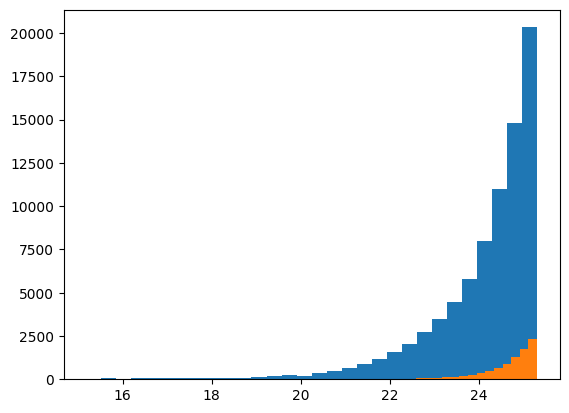

In [120]:
plt.hist(dets_lsst[(dets_lsst['mag_i']<25.3)&(dets_lsst['significant_blend'])]['mag_i'],bins=30);
plt.hist(dets_lsst[(dets_lsst['mag_i']<25.3)&(dets_lsst['significant_blend'])&(dets_lsst['lsst_is_unrec_blend'])]['mag_i'],bins=30);

In [27]:

def compute_unrec_blend_by_det(dets,prefix, mag_bins, mag_col='mag_i',
                              min_count=1):
    valid = (np.isfinite(dets[mag_col].values) & (dets['significant_blend']))
    results =  binned_fraction(
        dets[f'{prefix}_is_unrec_blend'].values[valid],
        dets[mag_col].values[valid],
        mag_bins,
        min_count=min_count,
    )

    return results
res = compute_unrec_blend_by_det(dets_lsst,'lsst', mag_bins, mag_col='mag_i',min_count=1)

In [34]:
res['bin_centers'][:-4]

array([18.25, 18.75, 19.25, 19.75, 20.25, 20.75, 21.25, 21.75, 22.25,
       22.75, 23.25, 23.75, 24.25, 24.75, 25.25, 25.75])

In [45]:
print(res['counts'][:-5])
res['counts'][:-5].sum()

[  119   159   266   316   450   712  1113  1700  2635  4034  5712  8492
 13488 21143 33140]


np.int64(93479)

In [46]:
print(res['flagged_counts'][:-5])

res['flagged_counts'][:-5].sum()

[   0    0    1    2    3   12   14   41   84  151  306  599 1331 2968
 6253]


np.int64(11765)

In [56]:
res['flagged_counts'][:-6].sum()/res['counts'][:-6].sum()

np.float64(0.09135053613748985)

In [63]:
def return_samples(truths,dets,prefix,magcut=25.3):
    
    t_cut = truths[truths['mag_i']<magcut]
    #d_cut = dets[(np.isfinite(dets['mag_i'].values)) & (dets['mag_i']<magcut)]
    d_cut = dets[dets['mag_i']<magcut]

    n_tcut = len(t_cut)
    n_tcut_matched = len(t_cut[t_cut[f'{prefix}_is_matched']])
    n_tcut_shred = len(t_cut[t_cut[f'{prefix}_is_shredded']])
    
    n_dcut = len(d_cut)
    n_dcut_sigblend = len(d_cut[d_cut['significant_blend']])
    n_dcut_blend = len(d_cut[(d_cut[f'{prefix}_is_part_of_blend'])&(d_cut['significant_blend'])])
    
    n_dcut_matched = len(d_cut[d_cut[f'{prefix}_is_matched']])
    n_dcut_unrec = len(d_cut[(d_cut[f'{prefix}_is_unrec_blend'])&(d_cut['significant_blend'])])
    n_dcut_resolved = len(d_cut[(d_cut[f'{prefix}_is_resolved_blend']) &(d_cut['significant_blend'])])
    n_dcut_partial = len(d_cut[(d_cut[f'{prefix}_is_partial_deblend'])&(d_cut['significant_blend'])])

    n_dcut_shred_blend = len(d_cut[(d_cut[f'{prefix}_is_part_of_blend']) & (d_cut[f'{prefix}_is_shred']) &(d_cut['significant_blend'])])

    return n_tcut, n_tcut_matched, n_tcut_shred, n_dcut, n_dcut_sigblend, n_dcut_blend, n_dcut_matched, n_dcut_unrec, n_dcut_resolved, n_dcut_partial, n_dcut_shred_blend
    
(n_lsst_tcut, n_lsst_tcut_matched, n_lsst_tcut_shred, n_lsst_dcut, n_lsst_dcut_sigblend, n_lsst_dcut_blend, n_lsst_dcut_matched, 
n_lsst_dcut_unrec, n_lsst_dcut_resolved, n_lsst_dcut_partial, n_lsst_dcut_shred_blend) = return_samples(truths_lsst,dets_lsst,prefix='lsst',magcut=25.3)

(n_dd_tcut, n_dd_tcut_matched, n_dd_tcut_shred, n_dd_dcut, n_dd_dcut_sigblend, n_dd_dcut_blend, n_dd_dcut_matched, 
n_dd_dcut_unrec, n_dd_dcut_resolved, n_dd_dcut_partial,n_dd_dcut_shred_blend) = return_samples(truths_dd,dets_dd,prefix='dd',magcut=25.3)

print('DeepDISC')
print(f'Total objects (i mag <25.3):  {n_dd_tcut}')
print(f'Total matched detections (i mag <25.3):  {n_dd_tcut_matched}')
print(f'Total detections (i mag <25.3):  {n_dd_dcut}')
print(f'Completeness (i mag <25.3): {n_dd_tcut_matched/n_dd_tcut:.4f}') 
print(f'Precision (i mag <25.3): {n_dd_dcut_matched/n_dd_dcut:.4f}') 
print(f'Shred fraction (i mag <25.3): {n_dd_tcut_shred/n_dd_tcut:.4f}') 
print(f'Unrec Blend fraction (i mag <25.3): {n_dd_dcut_unrec/n_dd_dcut_sigblend:.4f}') 
#print(f'Resolved Blend fraction (i mag <25.3): {n_dd_dcut_resolved/n_dd_dcut:.4f}') 
#print(f'Partial Deblend fraction (i mag <25.3): {n_dd_dcut_partial/n_dd_dcut:.4f}') 

print('\nLSST')
print(f'Total objects (i mag <25.3):  {n_lsst_tcut}')
print(f'Total matched detections (i mag <25.3):  {n_lsst_tcut_matched}')
print(f'Total detections (i mag <25.3):  {n_lsst_dcut}')
print(f'Completeness (i mag <25.3): {n_lsst_tcut_matched/n_lsst_tcut:.4f}') 
print(f'Shred fraction (i mag <25.3): {n_lsst_tcut_shred/n_lsst_tcut:.4f}') 
print(f'Precision (i mag <25.3): {n_lsst_dcut_matched/n_lsst_dcut:.4f}') 
print(f'Unrec Blend fraction (i mag <25.3): {n_lsst_dcut_unrec/n_lsst_dcut_sigblend:.4f}')


DeepDISC
Total objects (i mag <25.3):  107085
Total matched detections (i mag <25.3):  101502
Total detections (i mag <25.3):  104252
Completeness (i mag <25.3): 0.9479
Precision (i mag <25.3): 0.9762
Shred fraction (i mag <25.3): 0.0054
Unrec Blend fraction (i mag <25.3): 0.0909

LSST
Total objects (i mag <25.3):  107085
Total matched detections (i mag <25.3):  97892
Total detections (i mag <25.3):  90748
Completeness (i mag <25.3): 0.9142
Shred fraction (i mag <25.3): 0.0011
Precision (i mag <25.3): 0.9889
Unrec Blend fraction (i mag <25.3): 0.1118


In [64]:
print('DeepDISC')
n_dd_close_tot = n_dd_dcut_blend - n_dd_dcut_shred_blend
print(f'Total blends (i mag <25.3):  {n_dd_close_tot}')
print(f'Unrec fraction (i mag <25.3): {n_dd_dcut_unrec/n_dd_close_tot:.4f}') 
print(f'Resolved fraction (i mag <25.3): {n_dd_dcut_resolved/n_dd_close_tot:.4f}') 
print(f'Partial fraction (i mag <25.3): {n_dd_dcut_partial/n_dd_close_tot:.4f}') 

n_lsst_close_tot = n_lsst_dcut_blend - n_lsst_dcut_shred_blend

print('\nLSST')
print(f'Total blends (i mag <25.3):  {n_lsst_close_tot}')
print(f'Unrec fraction (i mag <25.3): {n_lsst_dcut_unrec/n_lsst_close_tot:.4f}') 
print(f'Resolved Blend fraction (i mag <25.3): {n_lsst_dcut_resolved/n_lsst_close_tot:.4f}') 
print(f'Partial Deblend fraction (i mag <25.3): {n_lsst_dcut_partial/n_lsst_close_tot:.4f}') 


DeepDISC
Total blends (i mag <25.3):  11131
Unrec fraction (i mag <25.3): 0.7299
Resolved fraction (i mag <25.3): 0.2702
Partial fraction (i mag <25.3): 0.7299

LSST
Total blends (i mag <25.3):  8927
Unrec fraction (i mag <25.3): 0.9923
Resolved Blend fraction (i mag <25.3): 0.0077
Partial Deblend fraction (i mag <25.3): 0.9923


In [66]:
0.0077*100

0.77

In [71]:
(n_ddr_tcut, n_ddr_tcut_matched, n_ddr_tcut_shred, n_ddr_dcut, n_ddr_dcut_blend, n_ddr_dcut_matched, 
n_ddr_dcut_unrec, n_ddr_dcut_resolved, n_ddr_dcut_partial,n_ddr_dcut_shred_blend) = return_samples(truths_dd_roman,dets_dd_roman,prefix='dd',magcut=25.3)

In [72]:
print('DeepDISC (Rubin)')
print(f'Total objects (i mag <25.3):  {n_dd_tcut}')
print(f'Total detections (i mag <25.3):  {n_dd_tcut_matched}')
print(f'Completeness (i mag <25.3): {n_dd_tcut_matched/n_dd_tcut:.4f}') 
print(f'Precision (i mag <25.3): {n_dd_dcut_matched/n_dd_dcut:.4f}') 
print(f'Shred fraction (i mag <25.3): {n_dd_tcut_shred/n_dd_tcut:.4f}') 
print(f'Unrec Blend fraction (i mag <25.3): {n_dd_dcut_unrec/n_dd_dcut:.4f}') 
print(f'Resolved Blend fraction (i mag <25.3): {n_dd_dcut_resolved/n_dd_dcut:.4f}') 
print(f'Partial Deblend fraction (i mag <25.3): {n_lsst_dcut_partial/n_dd_dcut:.4f}') 

print('\nDeepDISC (Rubin+Roman)')
print(f'Total objects (i mag <25.3):  {n_ddr_tcut}')
print(f'Total detections (i mag <25.3):  {n_ddr_tcut_matched}')
print(f'Completeness (i mag <25.3): {n_ddr_tcut_matched/n_ddr_tcut:.4f}') 
print(f'Precision (i mag <25.3): {n_ddr_dcut_matched/n_ddr_dcut:.4f}') 
print(f'Shred fraction (i mag <25.3): {n_ddr_tcut_shred/n_ddr_tcut:.4f}') 
print(f'Unrec Blend fraction (i mag <25.3): {n_ddr_dcut_unrec/n_ddr_dcut:.4f}') 



DeepDISC (Rubin)
Total objects (i mag <25.3):  107085
Total detections (i mag <25.3):  101502
Completeness (i mag <25.3): 0.9479
Precision (i mag <25.3): 0.9762
Shred fraction (i mag <25.3): 0.0054
Unrec Blend fraction (i mag <25.3): 0.1797
Resolved Blend fraction (i mag <25.3): 0.0455
Partial Deblend fraction (i mag <25.3): 0.1854

DeepDISC (Rubin+Roman)
Total objects (i mag <25.3):  107085
Total detections (i mag <25.3):  103606
Completeness (i mag <25.3): 0.9675
Precision (i mag <25.3): 0.9773
Shred fraction (i mag <25.3): 0.0058
Unrec Blend fraction (i mag <25.3): 0.1379


In [73]:
n_ddr_close_tot = n_ddr_dcut_blend - n_ddr_dcut_shred_blend

print('DeepDISC')
print(f'Total blends (i mag <25.3):  {n_dd_close_tot}')
print(f'Unrec fraction (i mag <25.3): {n_dd_dcut_unrec/n_dd_close_tot:.4f}') 
print(f'Resolved fraction (i mag <25.3): {n_dd_dcut_resolved/n_dd_close_tot:.4f}') 
print(f'Partial fraction (i mag <25.3): {n_dd_dcut_partial/n_dd_close_tot:.4f}') 

print('\nDeepDISC (Rubin+Roman)')
print(f'Total blends (i mag <25.3):  {n_ddr_close_tot}')
print(f'Unrec fraction (i mag <25.3): {n_ddr_dcut_unrec/n_ddr_close_tot:.4f}') 
print(f'Resolved fraction (i mag <25.3): {n_ddr_dcut_resolved/n_ddr_close_tot:.4f}') 
print(f'Partial fraction (i mag <25.3): {n_ddr_dcut_partial/n_ddr_close_tot:.4f}') 


DeepDISC
Total blends (i mag <25.3):  23475
Unrec fraction (i mag <25.3): 0.7982
Resolved fraction (i mag <25.3): 0.2020
Partial fraction (i mag <25.3): 0.7982

DeepDISC (Rubin+Roman)
Total blends (i mag <25.3):  26130
Unrec fraction (i mag <25.3): 0.5898
Resolved fraction (i mag <25.3): 0.4103
Partial fraction (i mag <25.3): 0.5898


In [76]:
n_dd_dcut_unrec, n_ddr_dcut_unrec

(18737, 15411)

### Compare Mags

In [67]:

lsst_tcols = ['row_index', 'catalog_key', 'group_id', 'id', 'ra',
       'dec', 'mag_u',
       'mag_g', 'mag_r', 'mag_i', 'mag_z', 'mag_y', 'tract', 'patch', 'size']

lsst_dcols = ['row_index', 'catalog_key', 'group_id', 'id', 'parentObjectId', 'ra',
       'dec', 'mag_u','mag_g', 'mag_r', 'mag_i', 'mag_z', 'mag_y', 'lsst_matched_id', 'lsst_is_matched', 'lsst_sep_dist', 'lsst_is_spurious', 'lsst_is_shred',
       'lsst_is_shredded', 'lsst_is_missed', 'lsst_is_blended_away',
       'lsst_is_unrec_blend', 'lsst_is_part_of_blend',
       'lsst_is_resolved_blend', 'lsst_is_partial_deblend']

dd_tcols = ['row_index', 'catalog_key', 'group_id', 'id', 'ra_box', 'dec_box', 'ra',
       'dec', 'class',  'score', 'mag_u',
       'mag_g', 'mag_r', 'mag_i', 'mag_z', 'mag_y', 'size']

dd_dcols = ['row_index', 'catalog_key', 'group_id', 'id', 'ra_box', 'dec_box', 'ra',
       'dec', 'class',  'score', 'mag_u',
       'mag_g', 'mag_r', 'mag_i', 'mag_z', 'mag_y', 'dd_matched_id','dd_is_matched', 'dd_sep_dist',
       'dd_is_spurious', 'dd_is_shred', 'dd_is_shredded', 'dd_is_missed',
       'dd_is_blended_away', 'dd_is_unrec_blend', 'dd_is_part_of_blend',
       'dd_is_resolved_blend', 'dd_is_partial_deblend']
d_lsst = dets_lsst[lsst_dcols][dets_lsst['lsst_is_matched']]
t_lsst = truths_lsst[lsst_tcols][truths_lsst['lsst_is_matched']]
d_dd = dets_dd[dd_dcols][dets_dd['dd_is_matched']]
t_dd = truths_dd[dd_tcols][truths_dd['dd_is_matched']]


In [68]:
lsst_merge = d_lsst.merge(t_lsst, how='left', left_on='lsst_matched_id',right_on='row_index',suffixes=('_det','_truth'))
dd_merge = d_dd.merge(t_dd, how='left', left_on='dd_matched_id',right_on='row_index',suffixes=('_det','_truth'))
#Change ID dtype since it gets converted to float in the above merge
dd_merge['id_truth'] = dd_merge['id_truth'].astype('Int64')
dd_merge['id_det'] = dd_merge['id_det'].astype('Int64')

lsst_merge['id_truth'] = lsst_merge['id_truth'].astype('Int64')
lsst_merge['id_det'] = lsst_merge['id_det'].astype('Int64')

In [69]:
#del truths_dd, dets_dd, truths_lsst, dets_lsst
total_merge = dd_merge.merge(lsst_merge,on='id_truth',how='left',suffixes=('_dd','_lsst'))
total_merge.dropna(subset=['mag_i_det_dd', 'mag_i_det_lsst'],inplace=True)

Text(0.5, 1.0, 'PSF mag')

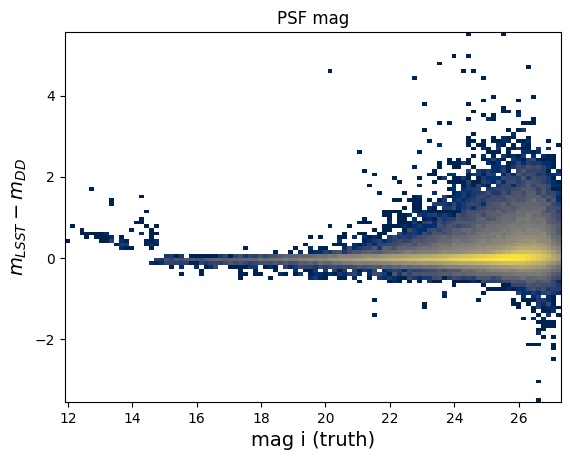

In [17]:
import matplotlib.colors as colors
plt.hist2d(total_merge['mag_i_truth_dd'],total_merge['mag_i_det_lsst']-total_merge['mag_i_det_dd'],
           bins=100,norm=colors.LogNorm(),cmap='cividis');
#plt.axhline(0,color='k')
#plt.axhline(1,color='k')
#plt.axhline(-1,color='k')
#plt.xlim(12,27.3)
plt.xlabel('mag i (truth)',fontsize=14)
plt.ylabel(r'$m_{LSST} - m_{DD}$',fontsize=14)
plt.title('PSF mag')

Text(0, 0.5, '$m_{LSST} - m_{DD}$')

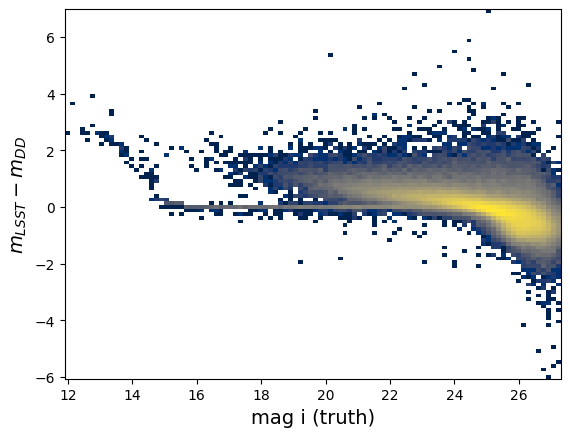

In [21]:
import matplotlib.colors as colors
plt.hist2d(total_merge['mag_i_truth_dd'],total_merge['mag_i_det_lsst']-total_merge['mag_i_det_dd'],
           bins=100,norm=colors.LogNorm(),cmap='cividis');
#plt.axhline(0,color='k')
#plt.axhline(1,color='k')
#plt.axhline(-1,color='k')
#plt.xlim(12,27.3)
plt.xlabel('mag i (truth)',fontsize=14)
plt.ylabel(r'$m_{LSST} - m_{DD}$',fontsize=14)

Text(0, 0.5, 'mag i (LSST)')

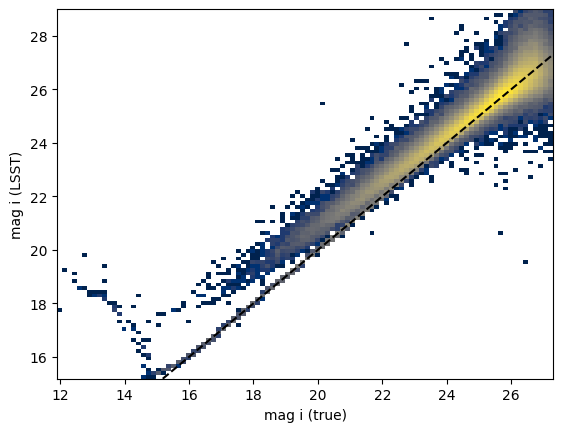

In [43]:
fig,ax = plt.subplots(1,1)
plt.hist2d(total_merge['mag_i_truth_lsst'],total_merge['mag_i_det_lsst'],
           bins=100,norm=colors.LogNorm(),cmap='cividis');
ax.axline((0, 0), (1, 1), color='k', linestyle='--')

plt.xlabel('mag i (true)')
plt.ylabel('mag i (LSST)')

#plt.savefig('/work/hdd/bdsp/g4merz/RubinRoman/plots/mag_lsst_vs_true.png')

In [ ]:
fig,ax = plt.subplots(1,1)
plt.hist2d(total_merge['mag_i_truth_dd'],total_merge['mag_i_det_dd'],
           bins=100,norm=colors.LogNorm(),cmap='cividis');
ax.axline((0, 0), (1, 1), color='k', linestyle='--')

plt.xlabel('mag i (true)')
plt.ylabel('mag i (DeepDISC)')

plt.savefig('/work/hdd/bdsp/g4merz/RubinRoman/plots/mag_dd_vs_true.png')

Text(0.5, 0, 'Mag i')

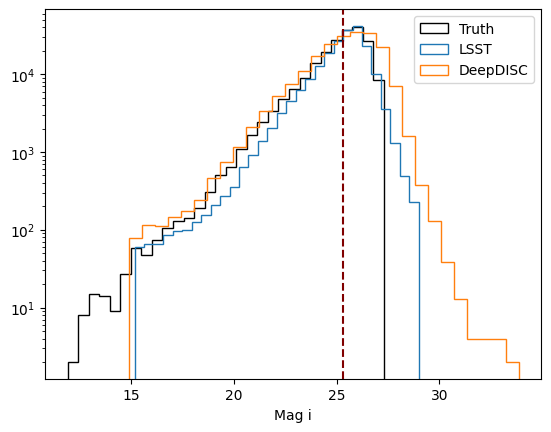

In [89]:
plt.hist(total_merge['mag_i_truth_dd'],histtype='step',bins=30,label='Truth',color='k',log=True)
plt.hist(total_merge['mag_i_det_lsst'],histtype='step',bins=30,label='LSST',log=True)
plt.hist(total_merge['mag_i_det_dd'],histtype='step',bins=30,label='DeepDISC',log=True)
plt.legend(loc=0)
plt.axvline(25.3,color='maroon',linestyle='--')
plt.xlabel('Mag i')

### Properties of unrec blend systems

In [70]:
#Unrec blends for each catalog
lsst_unrecs = lsst_merge[lsst_merge['lsst_is_unrec_blend']]
dd_unrecs = dd_merge[dd_merge['dd_is_unrec_blend']]

lsst_unrecs = lsst_unrecs[lsst_unrecs['mag_i_det']<25.3]
dd_unrecs = dd_unrecs[dd_unrecs['mag_i_det']<25.3]

In [71]:
#Unrec blends in both catalogs
unrecs_both = dd_unrecs.merge(lsst_unrecs,how='inner',on='id_truth',suffixes=('_dd','_lsst'))

In [72]:
#Unrec blends from LSST but not DD
lsst_unrecs_unique = lsst_unrecs[np.isin(lsst_unrecs['id_truth'].values,dd_unrecs['id_truth'].values,invert=True)]
dd_unrecs_unique = dd_unrecs[np.isin(dd_unrecs['id_truth'].values,lsst_unrecs['id_truth'].values,invert=True)]


In [112]:
#for c in unrecs_both.columns:
#    print(c)

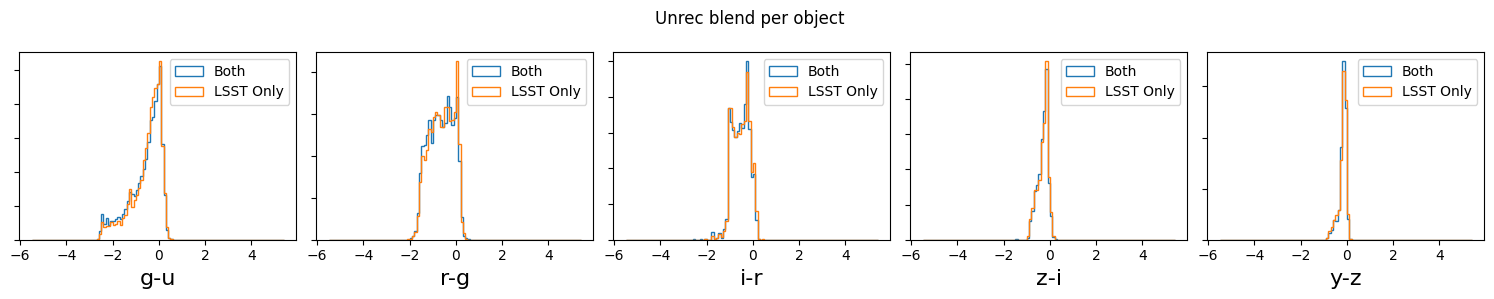

In [113]:
filters = ['u','g','r','i','z','y']
fig,ax = plt.subplots(1,5,figsize=(15,3))
for i in range(len(filters)-1):
    c1 = filters[i+1]
    c2 = filters[i]
    color_both = unrecs_both[f'mag_{c1}_truth_lsst'] - unrecs_both[f'mag_{c2}_truth_lsst']
    color_ulsst = lsst_unrecs_unique[f'mag_{c1}_truth'] - lsst_unrecs_unique[f'mag_{c2}_truth']
    ax[i].hist(color_both,bins=np.arange(-5.5,5.5,0.1),histtype='step',label='Both',density=True)
    ax[i].hist(color_ulsst,bins=np.arange(-5.5,5.5,0.1),histtype='step',label='LSST Only',density=True)
    ax[i].set_yticklabels([])
    ax[i].set_xlabel(f'{c1}-{c2}',fontsize=16)
    ax[i].legend(loc=0)
plt.suptitle('Unrec blend per object')
plt.tight_layout()
plt.savefig('/work/hdd/bdsp/g4merz/RubinRoman/plots/ubf_colors_lsst.jpg')

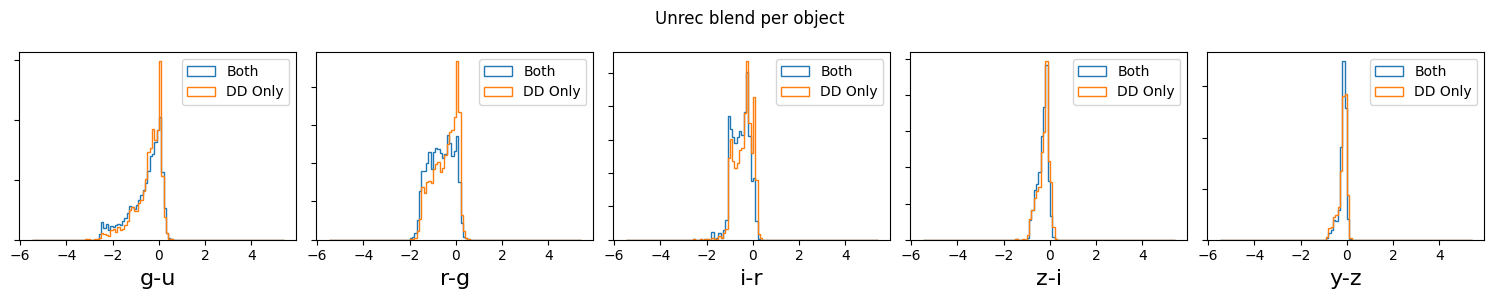

In [114]:

fig,ax = plt.subplots(1,5,figsize=(15,3))
for i in range(len(filters)-1):
    c1 = filters[i+1]
    c2 = filters[i]
    color_both = unrecs_both[f'mag_{c1}_truth_dd'] - unrecs_both[f'mag_{c2}_truth_dd']
    color_udd = dd_unrecs_unique[f'mag_{c1}_truth'] - dd_unrecs_unique[f'mag_{c2}_truth']
    ax[i].hist(color_both,bins=np.arange(-5.5,5.5,0.1),histtype='step',label='Both',density=True)
    ax[i].hist(color_udd,bins=np.arange(-5.5,5.5,0.1),histtype='step',label='DD Only',density=True)
    ax[i].set_yticklabels([])
    ax[i].set_xlabel(f'{c1}-{c2}',fontsize=16)
    ax[i].legend(loc=0)
plt.suptitle('Unrec blend per object')
plt.tight_layout()
plt.savefig('/work/hdd/bdsp/g4merz/RubinRoman/plots/ubf_colors_dd.jpg')

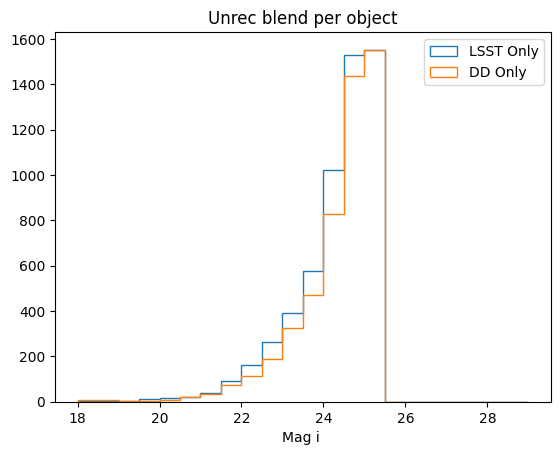

In [56]:
#plt.hist(unrecs_both['mag_i_truth_dd'],bins=np.arange(18,29.5,0.5),color='grey',density=True,alpha=0.5,label='Both');
plt.hist(lsst_unrecs_unique['mag_i_det'],bins=np.arange(18,29.5,0.5),histtype='step',density=False,label='LSST Only');
plt.hist(dd_unrecs_unique['mag_i_det'],bins=np.arange(18,29.5,0.5),histtype='step',density=False,label='DD Only');
plt.legend(loc=0)
plt.xlabel('Mag i ')
plt.title('Unrec blend per object')
plt.savefig('/work/hdd/bdsp/g4merz/RubinRoman/plots/ubf_mags.jpg')

In [156]:
lsst_unrecs_unique['size']

3         0.317592
7         0.218738
47        0.274675
48        0.423548
51        0.068966
            ...   
255291    0.205198
255295    0.117107
255320    0.135271
255339    0.217242
255359    0.142370
Name: size, Length: 5691, dtype: float64

Text(0.5, 1.0, 'Unrec blend per object')

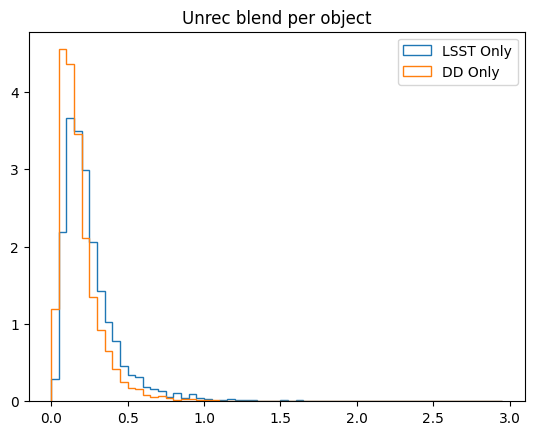

In [159]:
sb = np.arange(0,3,0.05)
plt.hist(lsst_unrecs_unique['size'],bins=sb,histtype='step',density=True,label='LSST Only');
plt.hist(dd_unrecs_unique['size'],bins=sb,histtype='step',density=True,label='DD Only');
plt.legend(loc=0)
#plt.xlabel('Mag i ')
plt.title('Unrec blend per object')
#plt.savefig('/work/hdd/bdsp/g4merz/RubinRoman/plots/ubf_mags.jpg')

In [80]:
#counts,ybins,xbins = np.histogram2d(unrecs_both['mag_i_truth_lsst'],unrecs_both['mag_i_det_lsst'],bins=np.arange(18,29.5,0.5));
#plt.contour(xbins[:-1],ybins[:-1],counts,levels=10)

Unrec blend objects unique to either catalog do not seem to have disparate color or mag distributions

Likely due to group properties, e.g. mag of the brightest source in the group.  Let's check group properties

In [73]:
lsst_merge = t_lsst.merge(d_lsst, how='left', on='group_id',suffixes=('_truth','_det'))
#dd_merge = t_dd.merge(d_dd, how='left', left_on='dd_matched_id',right_on='row_index',suffixes=('_truth','_det'))
#Change ID dtype since it gets converted to float in the above merge
#dd_merge['id_truth'] = dd_merge['id_truth'].astype('Int64')
#dd_merge['id_det'] = dd_merge['id_det'].astype('Int64')

lsst_merge['id_truth'] = lsst_merge['id_truth'].astype('Int64')
lsst_merge['id_det'] = lsst_merge['id_det'].astype('Int64')

In [94]:
def return_grouped_by_minmax_mag(df,prefix='lsst',deltam=2.0):
    #group_counts = df.groupby('group_id').size().reset_index(name='object_count')
    #gdf = df.groupby('group_id').filter(lambda x: x[f'{prefix}_is_unrec_blend'].all())
    #gdf['group_counts'] = gdf.groupby('group_id').transform('size')

    gdf = df.copy()
    group_counts = df.groupby('group_id').size().reset_index(name='object_count')
    gdf['group_counts'] = gdf.groupby('group_id').transform('size')

    for f in ['u','g','r','i','z','y']:
        gdf[f'min_blend_mag_{f}'] = gdf[f'mag_{f}'].where(gdf['catalog_key'] == f'lsst_truth').groupby(gdf['group_id']).transform('min')
        gdf[f'max_blend_mag_{f}'] = gdf[f'mag_{f}'].where(gdf['catalog_key'] == f'lsst_truth').groupby(gdf['group_id']).transform('max')
        
    gdf[f'min_size'] = gdf[f'size'].where(gdf['catalog_key'] == f'lsst_truth').groupby(gdf['group_id']).transform('min')

    gdf['significant_blend'] = (gdf[f'max_blend_mag_i'] - gdf[f'min_blend_mag_i']) < deltam

    return gdf


In [166]:
grouped_lsst_df = return_grouped_by_minmax_mag(lsst_df)
glsst_det = grouped_lsst_df[grouped_lsst_df['catalog_key']=='lsst_det']
glsst_det = glsst_det[glsst_det['mag_i']<25.3]
glsst_det = glsst_det[glsst_det['significant_blend']]
glsst_det=glsst_det[glsst_det['lsst_is_unrec_blend']]
glsst_det = glsst_det.merge(truths_lsst[['row_index','size','mag_i']], how='left', left_on='lsst_matched_id', right_on='row_index',suffixes=('_det','_truth'))

In [167]:
grouped_dd_df = return_grouped_by_minmax_mag(dd_df,prefix='dd')
gdd_det = grouped_dd_df[grouped_dd_df['catalog_key']=='dd_det']
gdd_det = gdd_det[gdd_det['mag_i']<25.3]
gdd_det = gdd_det[gdd_det['significant_blend']]
gdd_det=gdd_det[gdd_det['dd_is_unrec_blend']]
gdd_det = gdd_det.merge(truths_lsst[['row_index','size','mag_i']], how='left', left_on='dd_matched_id', right_on='row_index',suffixes=('_det','_truth'))

In [169]:
#lsst_unrecs_unique = lsst_unrecs[np.isin(lsst_unrecs['id_truth'].values,dd_unrecs['id_truth'].values,invert=True)]
gdd_det_unique = gdd_det[np.isin(gdd_det['dd_matched_id'].values,glsst_det['lsst_matched_id'].values,invert=True)]
glsst_det_unique = glsst_det[np.isin(glsst_det['lsst_matched_id'].values,gdd_det['dd_matched_id'].values,invert=True)]


In [153]:
print(len(glsst_det), len(glsst_det_unique))
print(len(gdd_det), len(gdd_det_unique))

8858 3759
8125 3026


Text(0.5, 0.98, 'LSST All UB')

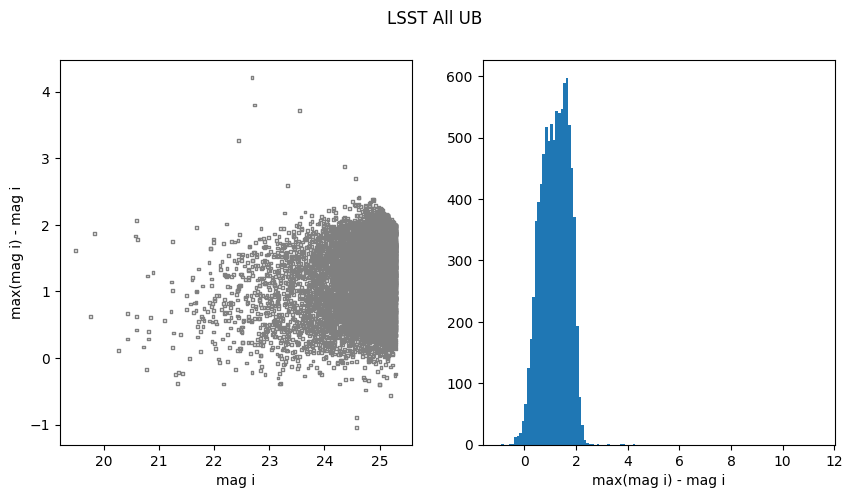

In [154]:
fig,ax = plt.subplots(1,2,figsize=(10,5))
mb = np.arange(-1,11.5,0.1)
ax[0].scatter(glsst_det['mag_i'],glsst_det['max_blend_mag_i']-glsst_det['mag_i'],
              marker='s',facecolors='none',edgecolors='grey',s=4)
ax[1].hist(glsst_det['max_blend_mag_i']-glsst_det['mag_i'],bins=mb);
ax[0].set_xlabel('mag i')
ax[0].set_ylabel('max(mag i) - mag i')
ax[1].set_xlabel('max(mag i) - mag i')
plt.suptitle('LSST All UB')


Text(0.5, 0.98, 'DeepDISC All UB')

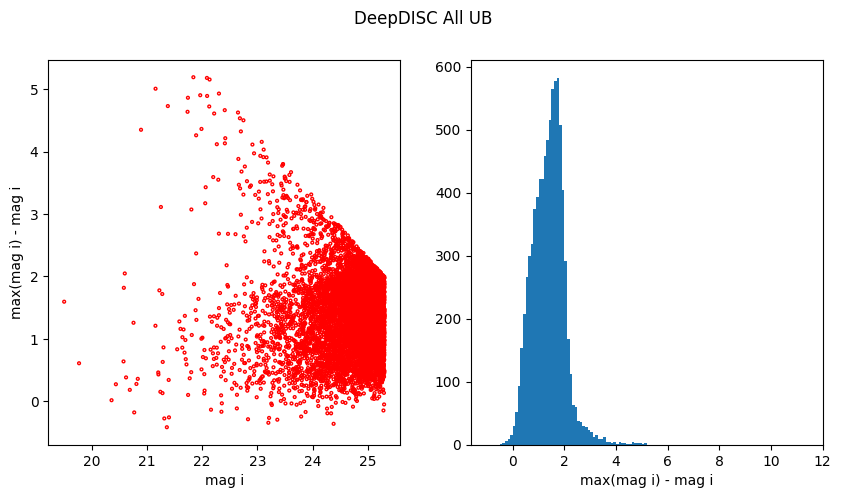

In [155]:
fig,ax = plt.subplots(1,2,figsize=(10,5))

ax[0].scatter(gdd_det['mag_i'],gdd_det['max_blend_mag_i']-gdd_det['mag_i'],
              marker='o',facecolors='none',edgecolors='red',s=4)
ax[1].hist(gdd_det['max_blend_mag_i']-gdd_det['mag_i'],bins=mb);
ax[0].set_xlabel('mag i')
ax[0].set_ylabel('max(mag i) - mag i')
ax[1].set_xlabel('max(mag i) - mag i')
plt.suptitle('DeepDISC All UB')


Text(0.5, 0.98, 'LSST Unique UB')

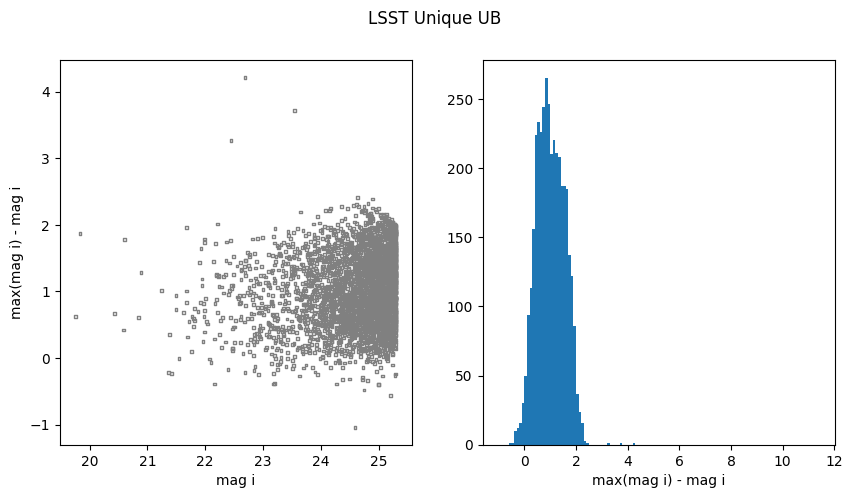

In [160]:
fig,ax = plt.subplots(1,2,figsize=(10,5))

ax[0].scatter(glsst_det_unique['mag_i'],glsst_det_unique['max_blend_mag_i']-glsst_det_unique['mag_i'],
              marker='s',facecolors='none',edgecolors='grey',s=4)
ax[1].hist(glsst_det_unique['max_blend_mag_i']-glsst_det_unique['mag_i'],bins=mb);
ax[0].set_xlabel('mag i')
ax[0].set_ylabel('max(mag i) - mag i')
ax[1].set_xlabel('max(mag i) - mag i')
plt.suptitle('LSST Unique UB')


Text(0.5, 0.98, 'DeepDISC Unique UB')

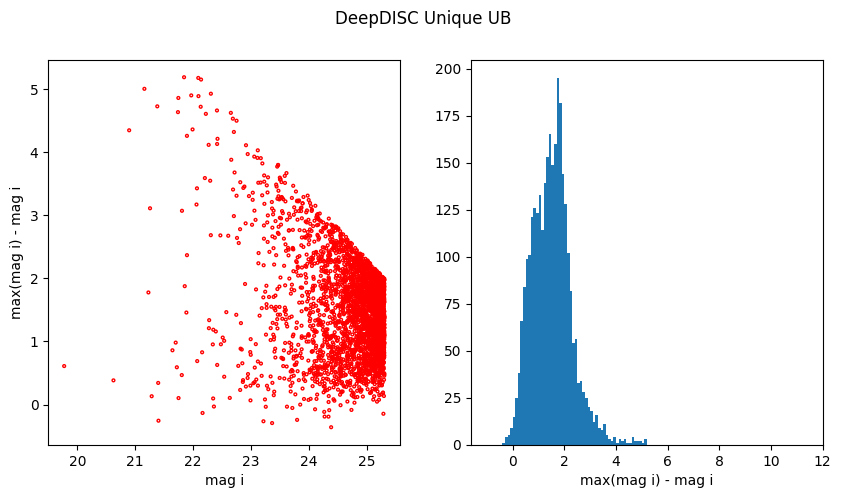

In [161]:
fig,ax = plt.subplots(1,2,figsize=(10,5))

ax[0].scatter(gdd_det_unique['mag_i'],gdd_det_unique['max_blend_mag_i']-gdd_det_unique['mag_i'],
              marker='o',facecolors='none',edgecolors='red',s=4)
ax[1].hist(gdd_det_unique['max_blend_mag_i']-gdd_det_unique['mag_i'],bins=mb);
ax[0].set_xlabel('mag i')
ax[0].set_ylabel('max(mag i) - mag i')
ax[1].set_xlabel('max(mag i) - mag i')
plt.suptitle('DeepDISC Unique UB')


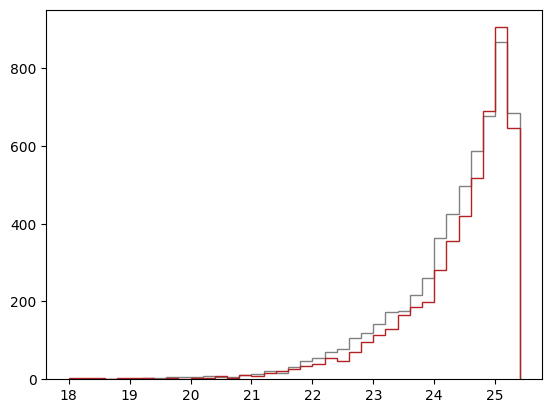

In [115]:
mb = np.arange(18,25.5,0.2)

plt.hist(glsst_det_unique['mag_i'],histtype='step',bins=mb,color='grey',label='LSST Only UB');
plt.hist(gdd_det_unique['mag_i'],histtype='step',bins=mb,color='firebrick',label='DeepDISC Only UB');


Text(0.5, 0.98, 'Urec Blend per Group')

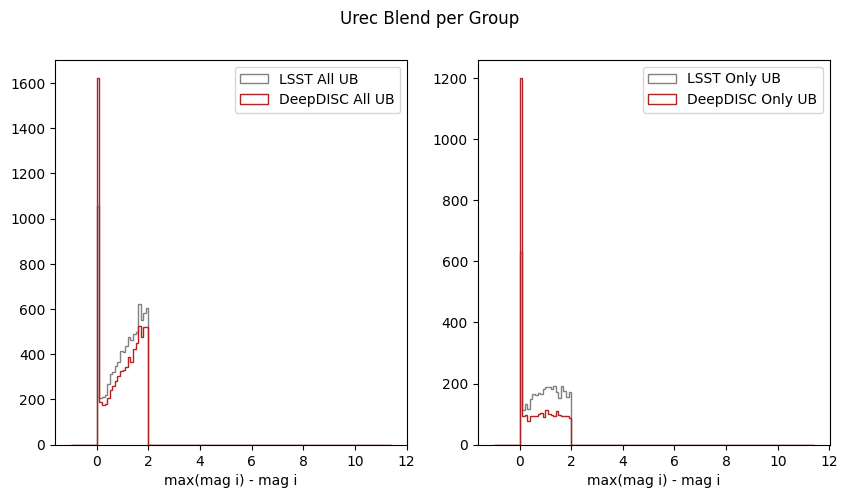

In [174]:
fig,ax = plt.subplots(1,2,figsize=(10,5))

mb = np.arange(-1,11.5,0.1)

ax[0].hist(glsst_det['max_blend_mag_i']-glsst_det['mag_i_truth'],histtype='step',bins=mb,color='grey',label='LSST All UB');
ax[0].hist(gdd_det['max_blend_mag_i']-gdd_det['mag_i_truth'],histtype='step',bins=mb,color='firebrick',label='DeepDISC All UB');
#plt.axvline(np.mean(glsst_det_unique['max_blend_mag_i']-glsst_det_unique['mag_i']),c='grey',linestyle='--')
#plt.axvline(np.mean(gdd_det_unique['max_blend_mag_i']-gdd_det_unique['mag_i']),c='firebrick',linestyle='--')
ax[0].legend(loc=0)
ax[0].set_xlabel('max(mag i) - mag i')

ax[1].hist(glsst_det_unique['max_blend_mag_i']-glsst_det_unique['mag_i_truth'],
           histtype='step',bins=mb,color='grey',label='LSST Only UB');
ax[1].hist(gdd_det_unique['max_blend_mag_i']-gdd_det_unique['mag_i_truth'],
           histtype='step',bins=mb,color='firebrick',label='DeepDISC Only UB');
#plt.axvline(np.mean(glsst_det_unique['max_blend_mag_i']-glsst_det_unique['mag_i']),c='grey',linestyle='--')
#plt.axvline(np.mean(gdd_det_unique['max_blend_mag_i']-gdd_det_unique['mag_i']),c='firebrick',linestyle='--')
ax[1].legend(loc=0)
ax[1].set_xlabel('max(mag i) - mag i')

plt.suptitle('Urec Blend per Group')
#plt.savefig('/work/hdd/bdsp/g4merz/RubinRoman/plots/ubf_group_magdif.jpg')

Text(0.5, 0.98, 'Urec Blend per Group')

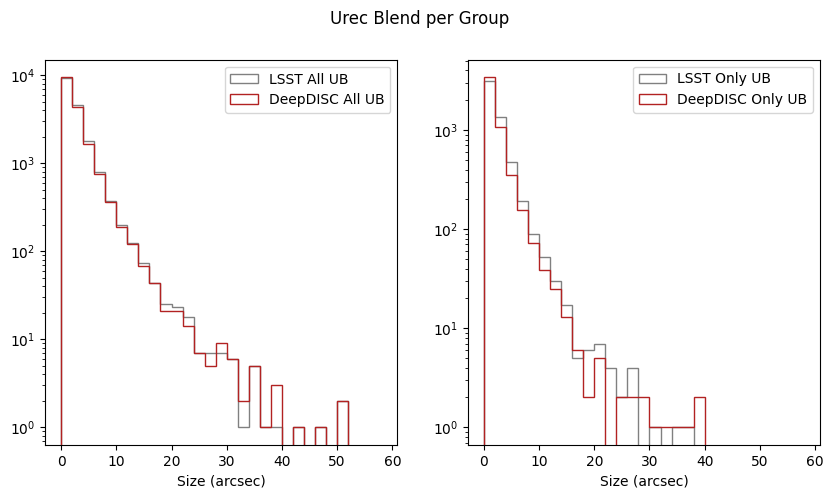

In [34]:
fig,ax = plt.subplots(1,2,figsize=(10,5))

sb = np.arange(0,60,2)

ax[0].hist(glsst_det['size_truth']/glsst_det['min_size'],histtype='step',color='grey',label='LSST All UB',log=True,bins=sb);
ax[0].hist(gdd_det['size_truth']/gdd_det['min_size'],histtype='step',color='firebrick',label='DeepDISC All UB',log=True,bins=sb);
#plt.axvline(np.mean(glsst_det_unique['max_blend_mag_i']-glsst_det_unique['mag_i']),c='grey',linestyle='--')
#plt.axvline(np.mean(gdd_det_unique['max_blend_mag_i']-gdd_det_unique['mag_i']),c='firebrick',linestyle='--')
ax[0].legend(loc=0)
ax[0].set_xlabel('Size (arcsec)')

ax[1].hist(glsst_det_unique['size_truth']/glsst_det_unique['min_size'],histtype='step',color='grey',label='LSST Only UB',log=True,bins=sb);
ax[1].hist(gdd_det_unique['size_truth']/gdd_det_unique['min_size'],histtype='step',color='firebrick',label='DeepDISC Only UB',log=True,bins=sb);
#plt.axvline(np.mean(glsst_det_unique['max_blend_mag_i']-glsst_det_unique['mag_i']),c='grey',linestyle='--')
#plt.axvline(np.mean(gdd_det_unique['max_blend_mag_i']-gdd_det_unique['mag_i']),c='firebrick',linestyle='--')
ax[1].legend(loc=0)
ax[1].set_xlabel('Size (arcsec)')

plt.suptitle('Urec Blend per Group')

#plt.savefig('/work/hdd/bdsp/g4merz/RubinRoman/plots/ubf_group_magdif.jpg')

In [107]:
2

2

In [26]:
#for c in lsst_df.columns:
#    print(c)